<a href="https://colab.research.google.com/github/swirita/Chicago-Crime-Analysis-and-Forecasting/blob/main/notebooks/02_crime_analysis_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Analysis & Forecasting

- Author: Siwar Ehwass

## Overview

## Imports

In [67]:
%pip install -q holidays

import pandas as pd
import numpy as np
import glob
import os

import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

## Load & Inspect Data

In [5]:
DATA_FOLDER = (
    "/content/drive/MyDrive/"
    "Chicago-Crime-Analysis-and-Forecasting/data/raw"
)

crime_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "Chicago-Crime_*.csv")))

print(f"Number of files found: {len(crime_files)}")
crime_files

Number of files found: 26


['/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2001.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2002.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2003.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2004.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2005.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2006.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2007.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2008.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2009.csv',
 '/content/drive/MyDrive/Chicago-Crime-Analysis-and-Forecasting/data/raw/Chicago-Crime_2010.csv',
 '/content/drive/MyD

In [6]:
def load_crime_file(file):
    temp_df = pd.read_csv(
        file,
        low_memory=False
    )

    temp_df["Date"] = pd.to_datetime(
        temp_df["Date"],
        format="%m/%d/%Y %I:%M:%S %p",
        errors="coerce"
    )

    return temp_df.dropna(subset=["Date"])

In [13]:
df = pd.concat(
    (load_crime_file(file) for file in crime_files),
    ignore_index=True
)

df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,5462733,2001-01-01 01:00:00,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,True,233,2.0,20.0,41.789084,-87.620849
1,1311933,2001-01-01 01:00:00,SEX OFFENSE,CRIMINAL SEXUAL ABUSE,RESIDENCE,True,False,1434,14.0,NaN,41.910797,-87.682214
2,1312658,2001-01-01 01:00:00,BATTERY,SIMPLE,STREET,False,False,2534,25.0,NaN,41.915450,-87.726575
3,1313213,2001-01-01 01:00:00,BATTERY,SIMPLE,VEHICLE NON-COMMERCIAL,False,True,731,7.0,NaN,41.765396,-87.626698
4,1315458,2001-01-01 01:00:00,THEFT,$500 AND UNDER,STREET,False,False,1421,14.0,NaN,41.910320,-87.702020


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8627693 entries, 0 to 8627692
Data columns (total 12 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   Date                  datetime64[ns]
 2   Primary Type          object        
 3   Description           object        
 4   Location Description  object        
 5   Arrest                bool          
 6   Domestic              bool          
 7   Beat                  int64         
 8   District              float64       
 9   Ward                  float64       
 10  Latitude              float64       
 11  Longitude             float64       
dtypes: bool(2), datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 674.7+ MB


## Feature Engineering: US Holidays

In [14]:
## making a date range that covers full dataset
all_days = pd.date_range(df["Date"].min(), df["Date"].max())
all_days

DatetimeIndex(['2001-01-01', '2001-01-02', '2001-01-03', '2001-01-04',
               '2001-01-05', '2001-01-06', '2001-01-07', '2001-01-08',
               '2001-01-09', '2001-01-10',
               ...
               '2026-08-16', '2026-08-17', '2026-08-18', '2026-08-19',
               '2026-08-20', '2026-08-21', '2026-08-22', '2026-08-23',
               '2026-08-24', '2026-08-25'],
              dtype='datetime64[ns]', length=9368, freq='D')

In [17]:
## Create an instance of the US country holidays.
us_holidays = country_holidays('US')
us_holidays

holidays.country_holidays('US')

In [21]:
## Saving holiday types as columns
df["US Holiday"] = [us_holidays.get(day) for day in df['Date']]
df.head(5)

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,US Holiday
0,5462733,2001-01-01 01:00:00,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,True,233,2.0,20.0,41.789084,-87.620849,New Year's Day
1,1311933,2001-01-01 01:00:00,SEX OFFENSE,CRIMINAL SEXUAL ABUSE,RESIDENCE,True,False,1434,14.0,NaN,41.910797,-87.682214,New Year's Day
2,1312658,2001-01-01 01:00:00,BATTERY,SIMPLE,STREET,False,False,2534,25.0,NaN,41.915450,-87.726575,New Year's Day
3,1313213,2001-01-01 01:00:00,BATTERY,SIMPLE,VEHICLE NON-COMMERCIAL,False,True,731,7.0,NaN,41.765396,-87.626698,New Year's Day
4,1315458,2001-01-01 01:00:00,THEFT,$500 AND UNDER,STREET,False,False,1421,14.0,NaN,41.910320,-87.702020,New Year's Day


In [22]:
## US Holidays
df['US Holiday'].value_counts()

,count
US Holiday,
New Year's Day,37240
Independence Day,25755
Labor Day,24506
Memorial Day,24069
Columbus Day,22935
Veterans Day,22348
Martin Luther King Jr. Day,20077
Washington's Birthday,20072
Thanksgiving Day,16245


/tmp/ipykernel_668/2717788790.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45, ha='right');


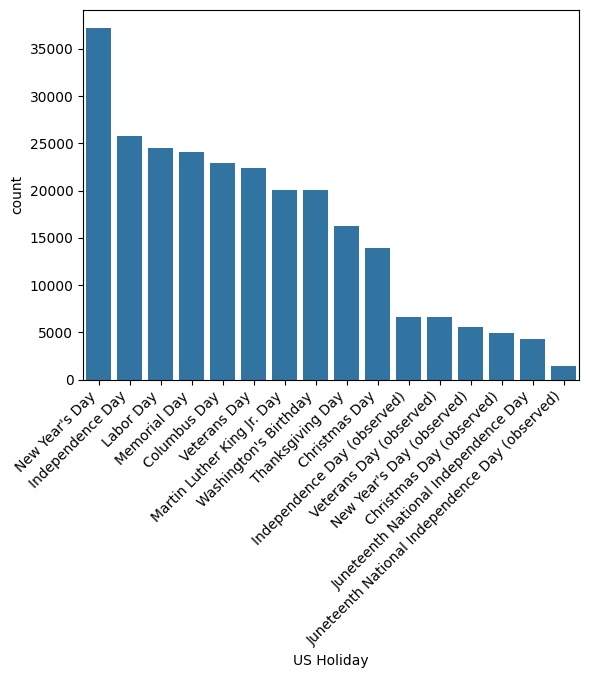

In [33]:
ax= sns.countplot(data=df, x="US Holiday", order=df["US Holiday"].value_counts().index)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45, ha='right');

In [34]:
## Saving a binary is holiday feature
df['Is_Holiday'] = df['US Holiday'].notna()
df['Is_Holiday'].value_counts()

,count
Is_Holiday,
False,8371203
True,256490


In [35]:
df = df.set_index("Date")

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8627693 entries, 2001-01-01 01:00:00 to 2026-08-25 00:00:00
Data columns (total 13 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Primary Type          object 
 2   Description           object 
 3   Location Description  object 
 4   Arrest                bool   
 5   Domestic              bool   
 6   Beat                  int64  
 7   District              float64
 8   Ward                  float64
 9   Latitude              float64
 10  Longitude             float64
 11  US Holiday            object 
 12  Is_Holiday            bool   
dtypes: bool(3), float64(4), int64(2), object(4)
memory usage: 748.7+ MB


In [36]:
print("Shape:", df.shape)
print("First date:", df.index.min())
print("Last date:", df.index.max())

df.head()

Shape: (8627693, 13)
First date: 2001-01-01 00:00:00
Last date: 2026-08-25 00:00:00


,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,US Holiday,Is_Holiday
Date,,,,,,,,,,,,,
2001-01-01 01:00:00,5462733,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,True,233,2.0,20.0,41.789084,-87.620849,New Year's Day,True
2001-01-01 01:00:00,1311933,SEX OFFENSE,CRIMINAL SEXUAL ABUSE,RESIDENCE,True,False,1434,14.0,NaN,41.910797,-87.682214,New Year's Day,True
2001-01-01 01:00:00,1312658,BATTERY,SIMPLE,STREET,False,False,2534,25.0,NaN,41.915450,-87.726575,New Year's Day,True
2001-01-01 01:00:00,1313213,BATTERY,SIMPLE,VEHICLE NON-COMMERCIAL,False,True,731,7.0,NaN,41.765396,-87.626698,New Year's Day,True
2001-01-01 01:00:00,1315458,THEFT,$500 AND UNDER,STREET,False,False,1421,14.0,NaN,41.910320,-87.702020,New Year's Day,True


In [40]:
df['ID'].duplicated().sum()

np.int64(0)

In [42]:
df['Primary Type'].isna().sum()

np.int64(0)

## Crimes Across the Years

- Is the total number of crimes increasing or decreasing across the years?
- Are there any individual crimes that are doing the opposite (e.g., decreasing when overall crime is increasing or vice-versa)?

In [68]:
annual_counts = df.resample('YS').size()
annual_counts.index = annual_counts.index.year
annual_counts.index.name = 'Year'
annual_counts.name = 'Number of Crimes'

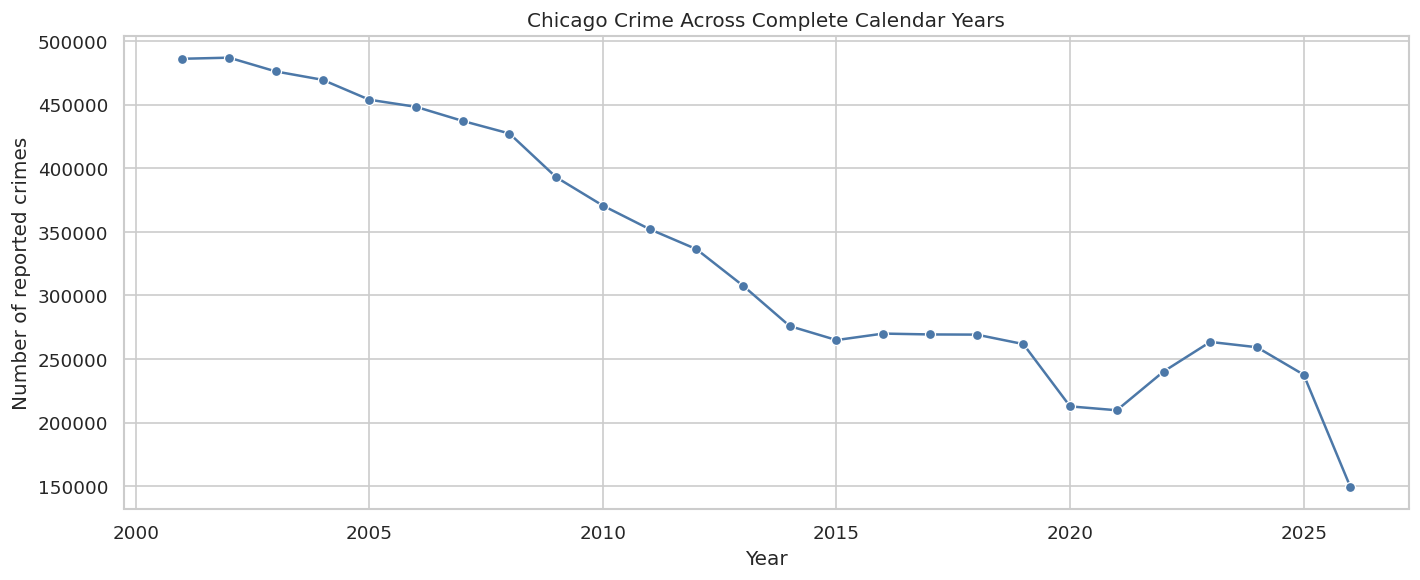

In [69]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    x=annual_counts.index,
    y=annual_counts.values,
    marker='o',
    color='#4C78A8',
    ax=ax
)
ax.set(
    title='Chicago Crime Across Complete Calendar Years',
    xlabel='Year',
    ylabel='Number of reported crimes'
)
ax.ticklabel_format(style='plain', axis='y')
fig.tight_layout()

In [70]:
crime_by_year = (df.groupby([df.index.year, 'Primary Type']).size().unstack(fill_value=0))
crime_by_year.index.name = 'Year'

start_average = crime_by_year.head(3).mean()
end_average = crime_by_year.tail(3).mean()
coverage = crime_by_year.gt(0).mean()
average_annual_count = crime_by_year.mean()
overall_window_change = annual_counts.tail(3).mean() - annual_counts.head(3).mean()

crime_changes = pd.DataFrame({
    'First 3-Year Average': start_average,
    'Last 3-Year Average': end_average,
    'Change in Annual Count': end_average - start_average,
    'Percent Change': (end_average / start_average - 1) * 100,
    'Year Coverage': coverage
})

eligible = (
    (crime_changes['Year Coverage'] >= 0.80)
    & (average_annual_count >= 100)
    & (crime_changes['First 3-Year Average'] >= 100)
)
opposite_mask = (
    crime_changes['Change in Annual Count'] * overall_window_change < 0
)

opposite_crimes = crime_changes.loc[eligible & opposite_mask].copy()
opposite_crimes = opposite_crimes.sort_values(
    'Change in Annual Count',
    ascending=overall_window_change > 0
)

opposite_crimes.head(10).round(1)

,First 3-Year Average,Last 3-Year Average,Change in Annual Count,Percent Change,Year Coverage
Primary Type,,,,,
WEAPONS VIOLATION,4257.0,5550.0,1293.0,30.4,1.0
INTERFERENCE WITH PUBLIC OFFICER,392.3,758.0,365.7,93.2,1.0
STALKING,217.0,501.0,284.0,130.9,1.0


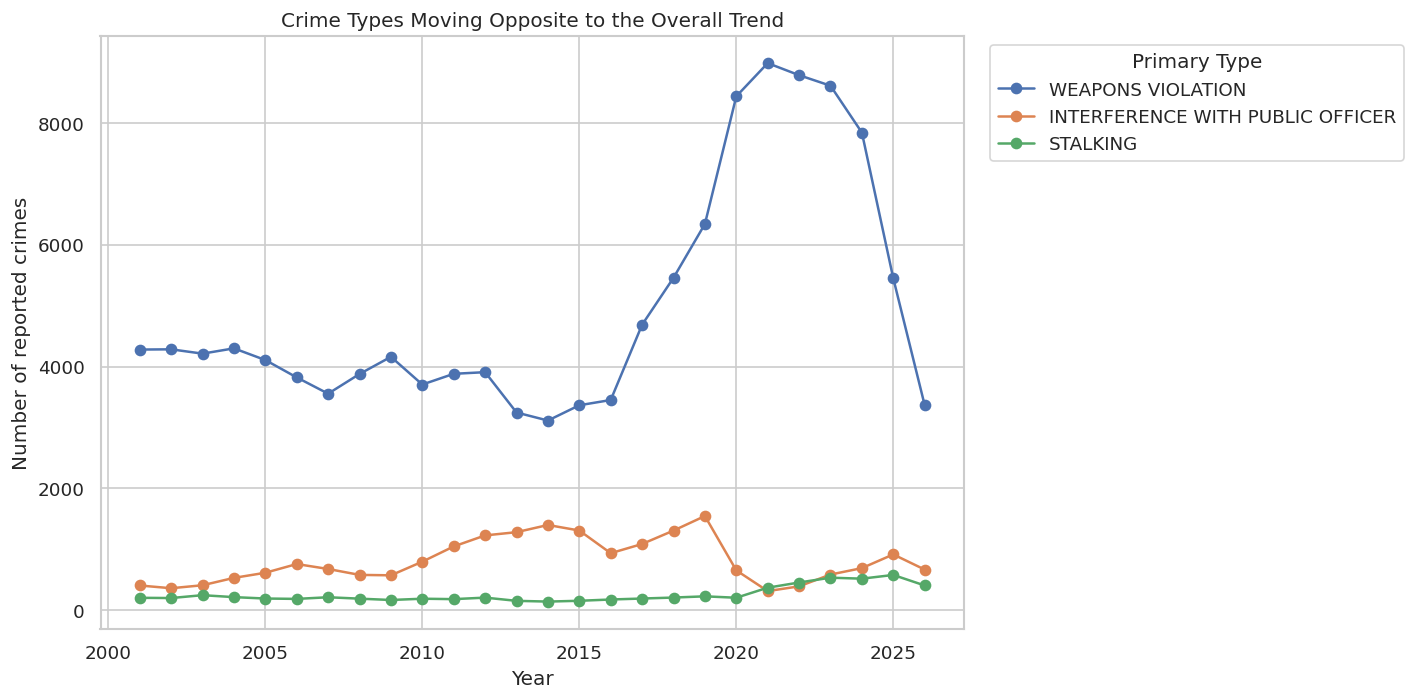

In [71]:
opposite_top = opposite_crimes.head(5).index.tolist()

if opposite_top:
    fig, ax = plt.subplots(figsize=(12, 6))
    crime_by_year[opposite_top].plot(ax=ax, marker='o')
    ax.set(
        title='Crime Types Moving Opposite to the Overall Trend',
        xlabel='Year',
        ylabel='Number of reported crimes'
    )
    ax.legend(title='Primary Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.tight_layout()
    plt.show()

## Comparing AM vs. PM Rush Hour:
- Are crimes more common during AM rush hour or PM rush hour?
- consider any crime that occurred between 7 AM - 10 AM as AM rush hour
, any crime that occurred between 4 - 7 PM as PM rush hour.

- What are the top 5 most common crimes during AM rush hour? What are the top 5 most common crimes during PM rush hour?

- Are Motor Vehicle Thefts more common during AM rush hour or PM Rush Hour?

In [72]:
hour = df.index.hour
am_mask = (hour >= 7) & (hour < 10)
pm_mask = (hour >= 16) & (hour < 19)

rush_df = df.loc[am_mask | pm_mask, ['Primary Type']].copy()
rush_df['Rush Hour'] = np.where(
    (rush_df.index.hour >= 7) & (rush_df.index.hour < 10),
    'AM Rush Hour',
    'PM Rush Hour'
)

rush_totals = (
    rush_df['Rush Hour']
    .value_counts()
    .reindex(['AM Rush Hour', 'PM Rush Hour'])
)
rush_totals

,count
Rush Hour,
AM Rush Hour,863343
PM Rush Hour,1352388


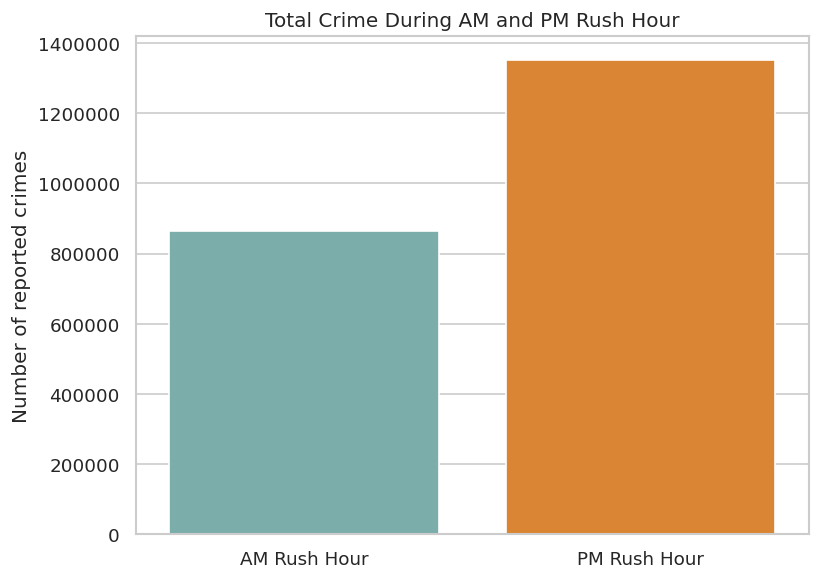

In [73]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    x=rush_totals.index,
    y=rush_totals.values,
    hue=rush_totals.index,
    palette=['#72B7B2', '#F58518'],
    legend=False,
    ax=ax
)
ax.set(
    title='Total Crime During AM and PM Rush Hour',
    xlabel='',
    ylabel='Number of reported crimes'
)
ax.ticklabel_format(style='plain', axis='y')
fig.tight_layout()
plt.show()

more_common_rush = rush_totals.idxmax()
difference = int(rush_totals.max() - rush_totals.min())

In [74]:
rush_type_counts = (
    rush_df
    .groupby(['Rush Hour', 'Primary Type'], observed=True)
    .size()
    .reset_index(name='Number of Crimes')
)

top5_rush = (
    rush_type_counts
    .sort_values(['Rush Hour', 'Number of Crimes'], ascending=[True, False])
    .groupby('Rush Hour', sort=False)
    .head(5)
)

for rush_name in ['AM Rush Hour', 'PM Rush Hour']:
    print(f'\n{rush_name}:')
    display(
        top5_rush.loc[top5_rush['Rush Hour'] == rush_name]
        [['Primary Type', 'Number of Crimes']]
        .reset_index(drop=True)
    )


AM Rush Hour:


,Primary Type,Number of Crimes
0,THEFT,206607
1,BATTERY,123474
2,CRIMINAL DAMAGE,91156
3,BURGLARY,77427
4,OTHER OFFENSE,69818



PM Rush Hour:


,Primary Type,Number of Crimes
0,THEFT,331085
1,BATTERY,237998
2,CRIMINAL DAMAGE,148549
3,NARCOTICS,107217
4,ASSAULT,104249


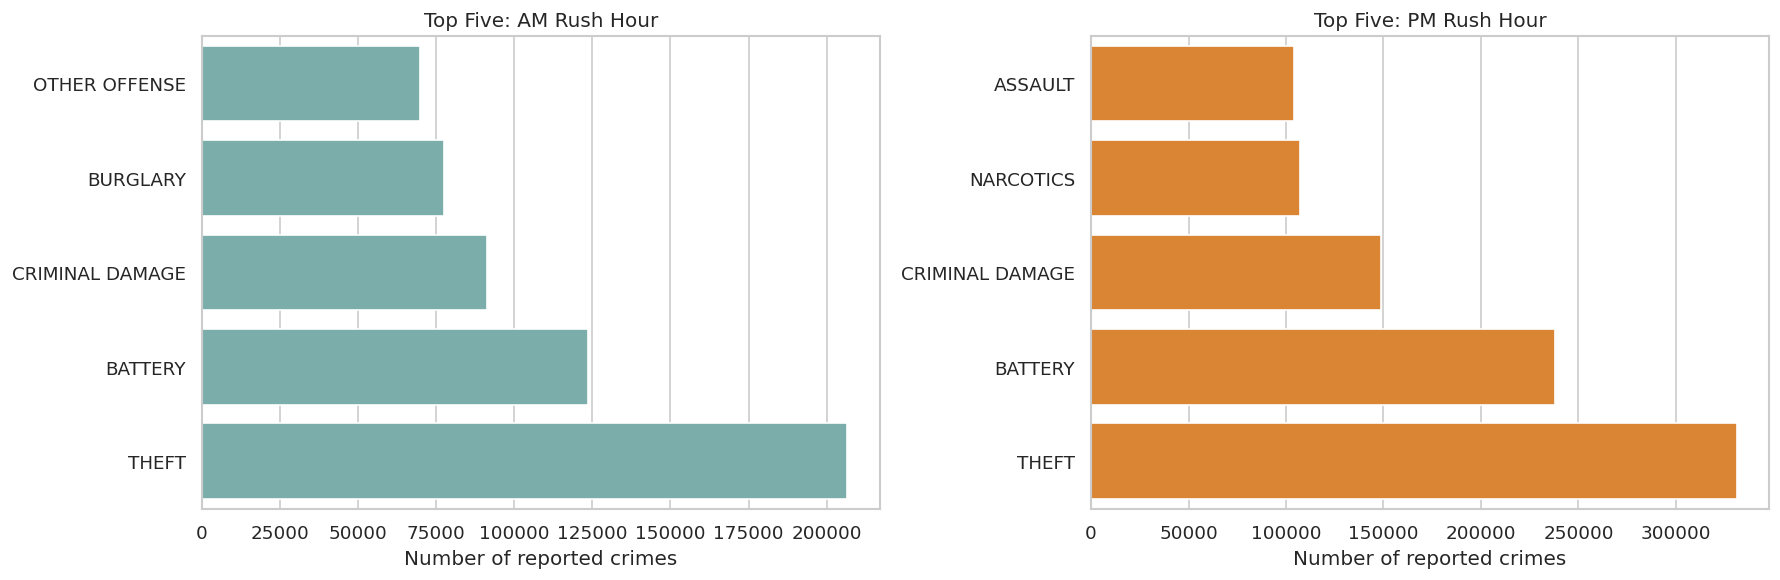

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=False)

for ax, rush_name, color in zip(
    axes,
    ['AM Rush Hour', 'PM Rush Hour'],
    ['#72B7B2', '#F58518']
):
    plot_df = (
        top5_rush.loc[top5_rush['Rush Hour'] == rush_name]
        .sort_values('Number of Crimes')
    )
    sns.barplot(
        data=plot_df,
        x='Number of Crimes',
        y='Primary Type',
        color=color,
        ax=ax
    )
    ax.set_title(f'Top Five: {rush_name}')
    ax.set_xlabel('Number of reported crimes')
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

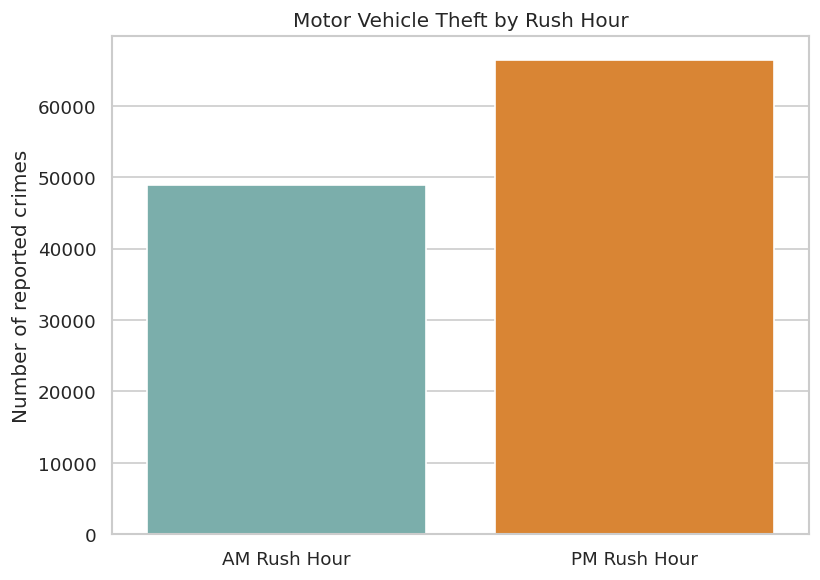

In [76]:
motor_vehicle_thefts = rush_df.loc[
    rush_df['Primary Type'] == 'MOTOR VEHICLE THEFT'
]
mvt_counts = (
    motor_vehicle_thefts['Rush Hour']
    .value_counts()
    .reindex(['AM Rush Hour', 'PM Rush Hour'], fill_value=0)
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    x=mvt_counts.index,
    y=mvt_counts.values,
    hue=mvt_counts.index,
    palette=['#72B7B2', '#F58518'],
    legend=False,
    ax=ax
)
ax.set(
    title='Motor Vehicle Theft by Rush Hour',
    xlabel='',
    ylabel='Number of reported crimes'
)
fig.tight_layout()
plt.show()

## Preprocessing

## Comparing Holidays

- What are the top 3 holidays with the largest number of crimes?

-  For each of the top 3 holidays with the most crime, what are the top 5 most common crimes on that holiday?

In [77]:
holiday_df = df.loc[df['US Holiday'].notna()].copy()
top3_holidays = holiday_df['US Holiday'].value_counts().head(3)

print('Top three holidays with the most crimes:')
display(top3_holidays.rename('Number of Crimes').to_frame())

Top three holidays with the most crimes:


,Number of Crimes
US Holiday,
New Year's Day,37240
Independence Day,25755
Labor Day,24506


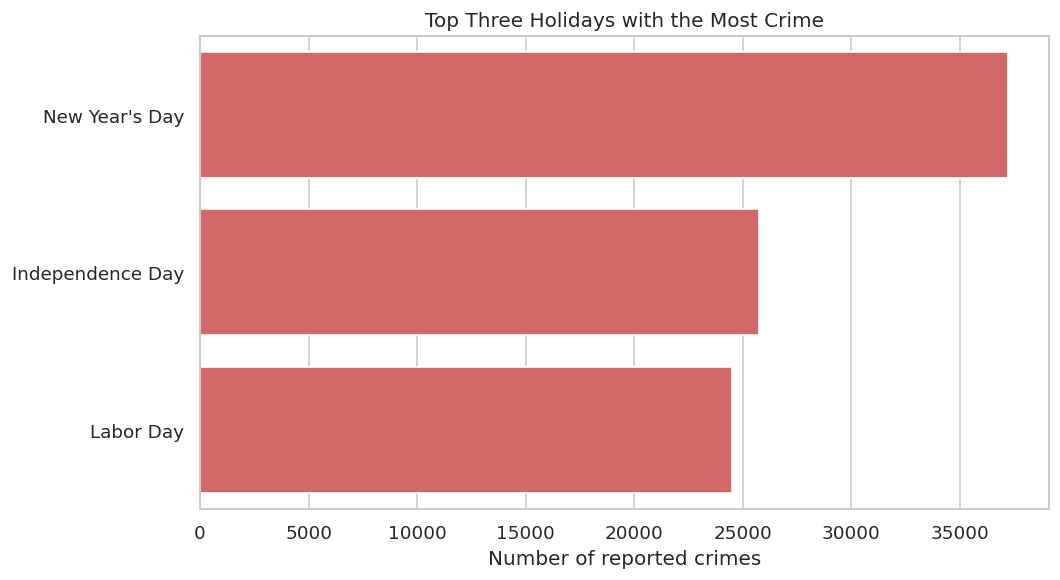

In [78]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    x=top3_holidays.values,
    y=top3_holidays.index,
    color='#E45756',
    ax=ax
)
ax.set(
    title='Top Three Holidays with the Most Crime',
    xlabel='Number of reported crimes',
    ylabel=''
)
fig.tight_layout()
plt.show()

In [79]:
## Top Five Crime Types on Each of the Top Three Holidays
top_holiday_names = top3_holidays.index.tolist()
top_holiday_crimes = (
    holiday_df.loc[holiday_df['US Holiday'].isin(top_holiday_names)]
    .groupby(['US Holiday', 'Primary Type'], observed=True)
    .size()
    .reset_index(name='Number of Crimes')
)
top5_by_holiday = (
    top_holiday_crimes
    .sort_values(['US Holiday', 'Number of Crimes'], ascending=[True, False])
    .groupby('US Holiday', sort=False)
    .head(5)
)

for holiday_name in top_holiday_names:
    print(f'\n{holiday_name}:')
    display(
        top5_by_holiday.loc[top5_by_holiday['US Holiday'] == holiday_name]
        [['Primary Type', 'Number of Crimes']]
        .reset_index(drop=True)
    )


New Year's Day:


,Primary Type,Number of Crimes
0,THEFT,7334
1,BATTERY,6883
2,CRIMINAL DAMAGE,3782
3,DECEPTIVE PRACTICE,3706
4,OTHER OFFENSE,2676



Independence Day:


,Primary Type,Number of Crimes
0,BATTERY,6495
1,THEFT,4618
2,CRIMINAL DAMAGE,3752
3,ASSAULT,1824
4,NARCOTICS,1590



Labor Day:


,Primary Type,Number of Crimes
0,BATTERY,5061
1,THEFT,4989
2,CRIMINAL DAMAGE,2768
3,NARCOTICS,2130
4,ASSAULT,1730


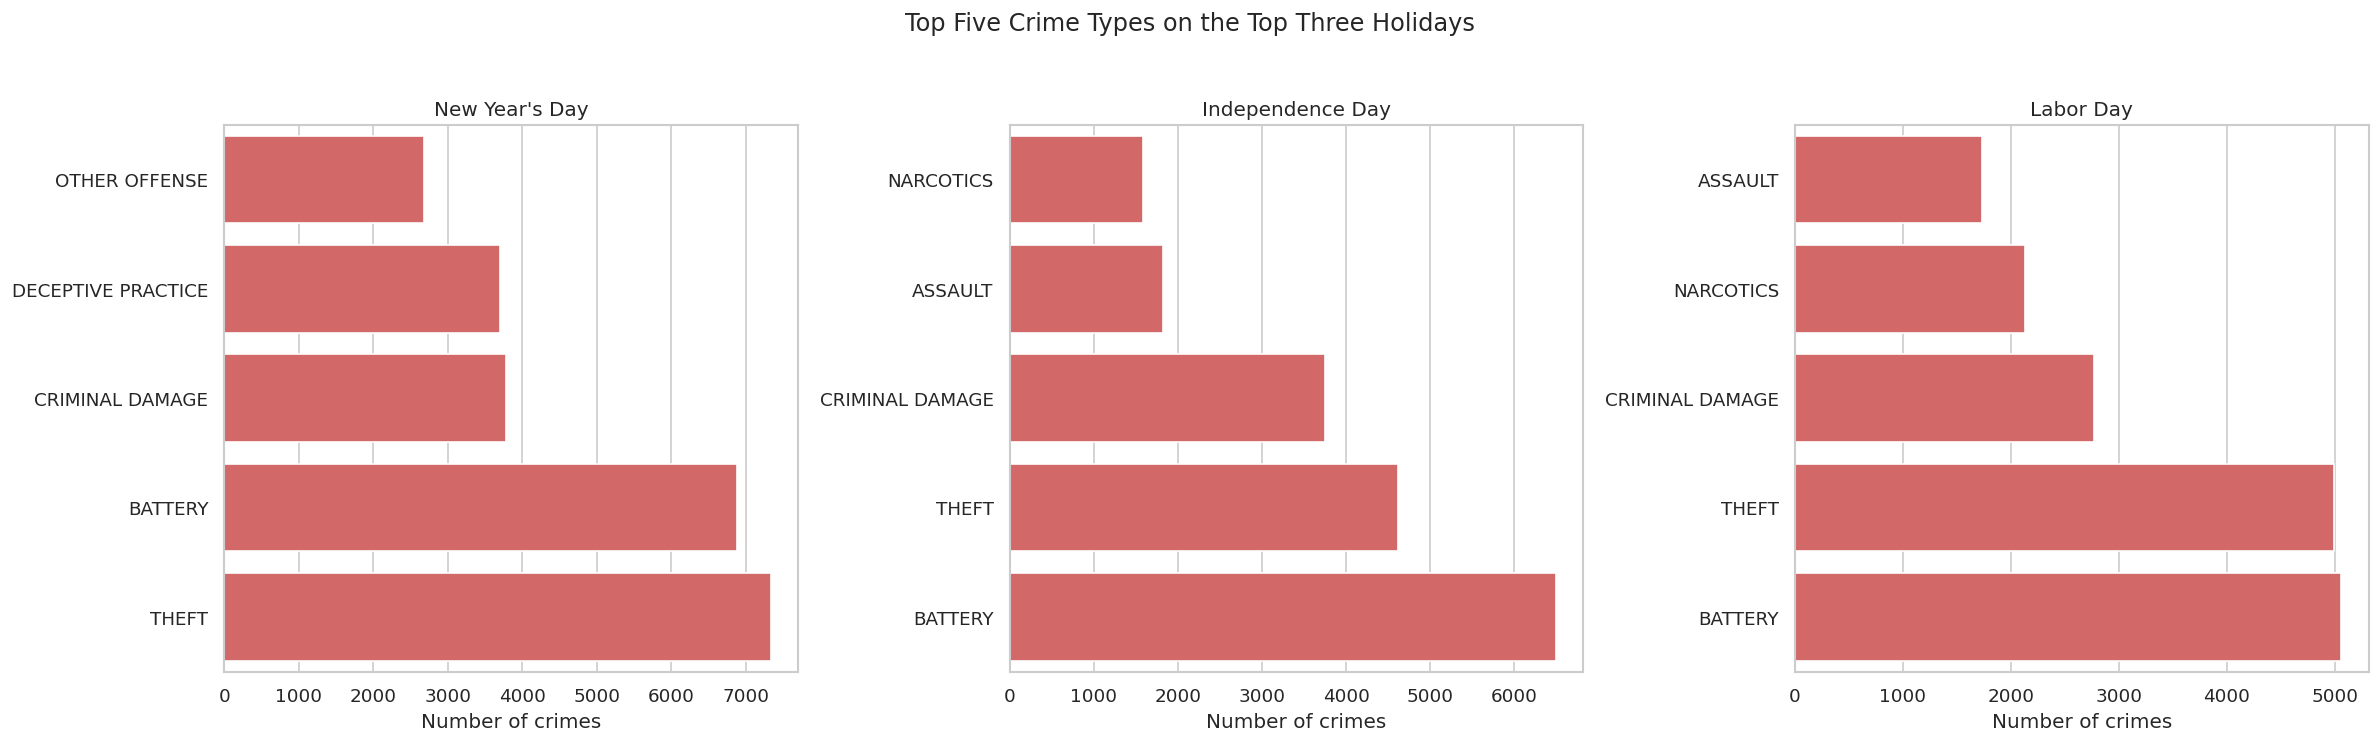

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, holiday_name in zip(axes, top_holiday_names):
    plot_df = (
        top5_by_holiday.loc[top5_by_holiday['US Holiday'] == holiday_name]
        .sort_values('Number of Crimes')
    )
    sns.barplot(
        data=plot_df,
        x='Number of Crimes',
        y='Primary Type',
        color='#E45756',
        ax=ax
    )
    ax.set_title(holiday_name)
    ax.set_xlabel('Number of crimes')
    ax.set_ylabel('')

fig.suptitle('Top Five Crime Types on the Top Three Holidays', y=1.03)
fig.tight_layout()
plt.show()

## Evaluation

# Crime Seasonality

Two cycles are tested with `seasonal_decompose()`:

1. Daily crime with a period of **7 days** to test a weekly cycle.
2. Monthly crime with a period of **12 months** to test an annual cycle.

The magnitude is the maximum seasonal effect minus the minimum seasonal effect. It is measured in number of crimes.

In [82]:
daily_counts = df.resample('D').size().asfreq('D', fill_value=0)
weekly_decomposition = seasonal_decompose(
    daily_counts,
    model='additive',
    period=7,
    extrapolate_trend='freq'
)

daily_counts.head()

,0
Date,
2001-01-01,1833
2001-01-02,1143
2001-01-03,1151
2001-01-04,1166
2001-01-05,1267


## Weekly Cycle: Full Decomposition

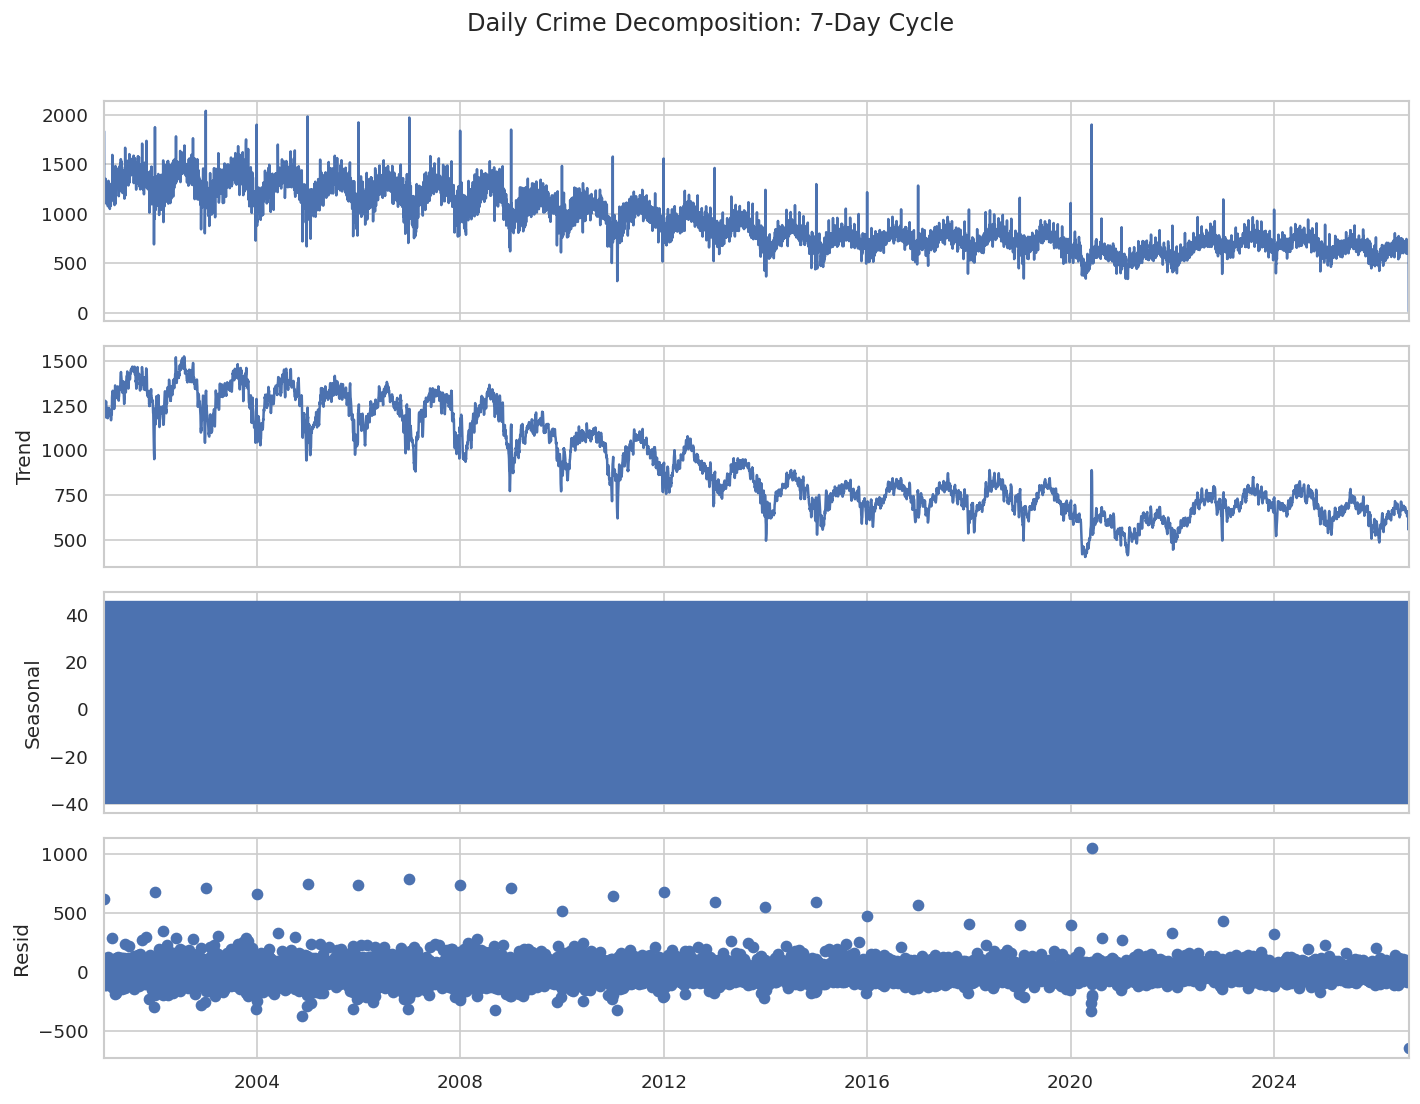

In [83]:
fig = weekly_decomposition.plot()
fig.set_size_inches(12, 9)
fig.suptitle('Daily Crime Decomposition: 7-Day Cycle', y=1.02)
fig.tight_layout()
plt.show()

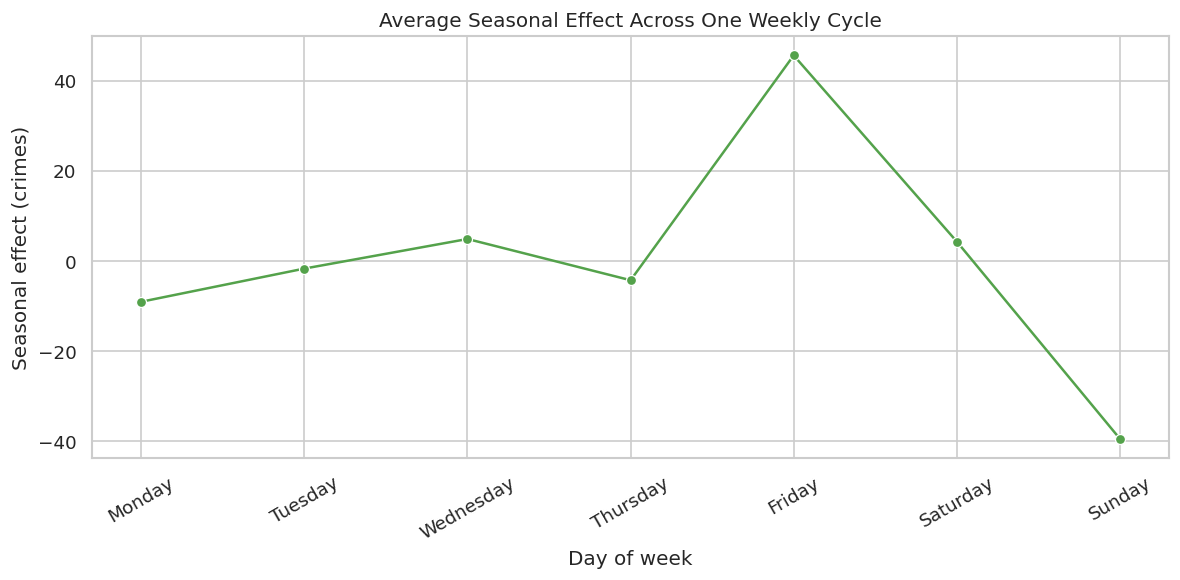

Cycle length: 7 days
Cycle magnitude: 85.1 crimes
Highest seasonal point: Friday
Lowest seasonal point: Sunday


In [85]:
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]
weekly_pattern = (
    weekly_decomposition.seasonal
    .groupby(weekly_decomposition.seasonal.index.day_name())
    .mean()
    .reindex(weekday_order)
)
weekly_magnitude = weekly_pattern.max() - weekly_pattern.min()
weekly_peak_day = weekly_pattern.idxmax()
weekly_low_day = weekly_pattern.idxmin()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    x=weekly_pattern.index,
    y=weekly_pattern.values,
    marker='o',
    color='#54A24B',
    ax=ax
)
ax.set(
    title='Average Seasonal Effect Across One Weekly Cycle',
    xlabel='Day of week',
    ylabel='Seasonal effect (crimes)'
)
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

print('Cycle length: 7 days')
print(f'Cycle magnitude: {weekly_magnitude:.1f} crimes')
print(f'Highest seasonal point: {weekly_peak_day}')
print(f'Lowest seasonal point: {weekly_low_day}')

In [86]:
monthly_counts = df.resample('MS').size()
annual_decomposition = seasonal_decompose(
    monthly_counts,
    model='additive',
    period=12,
    extrapolate_trend='freq'
)

monthly_counts.head()

,0
Date,
2001-01-01,38128
2001-02-01,33791
2001-03-01,40576
2001-04-01,40102
2001-05-01,41848


## Annual Cycle: Full Decomposition

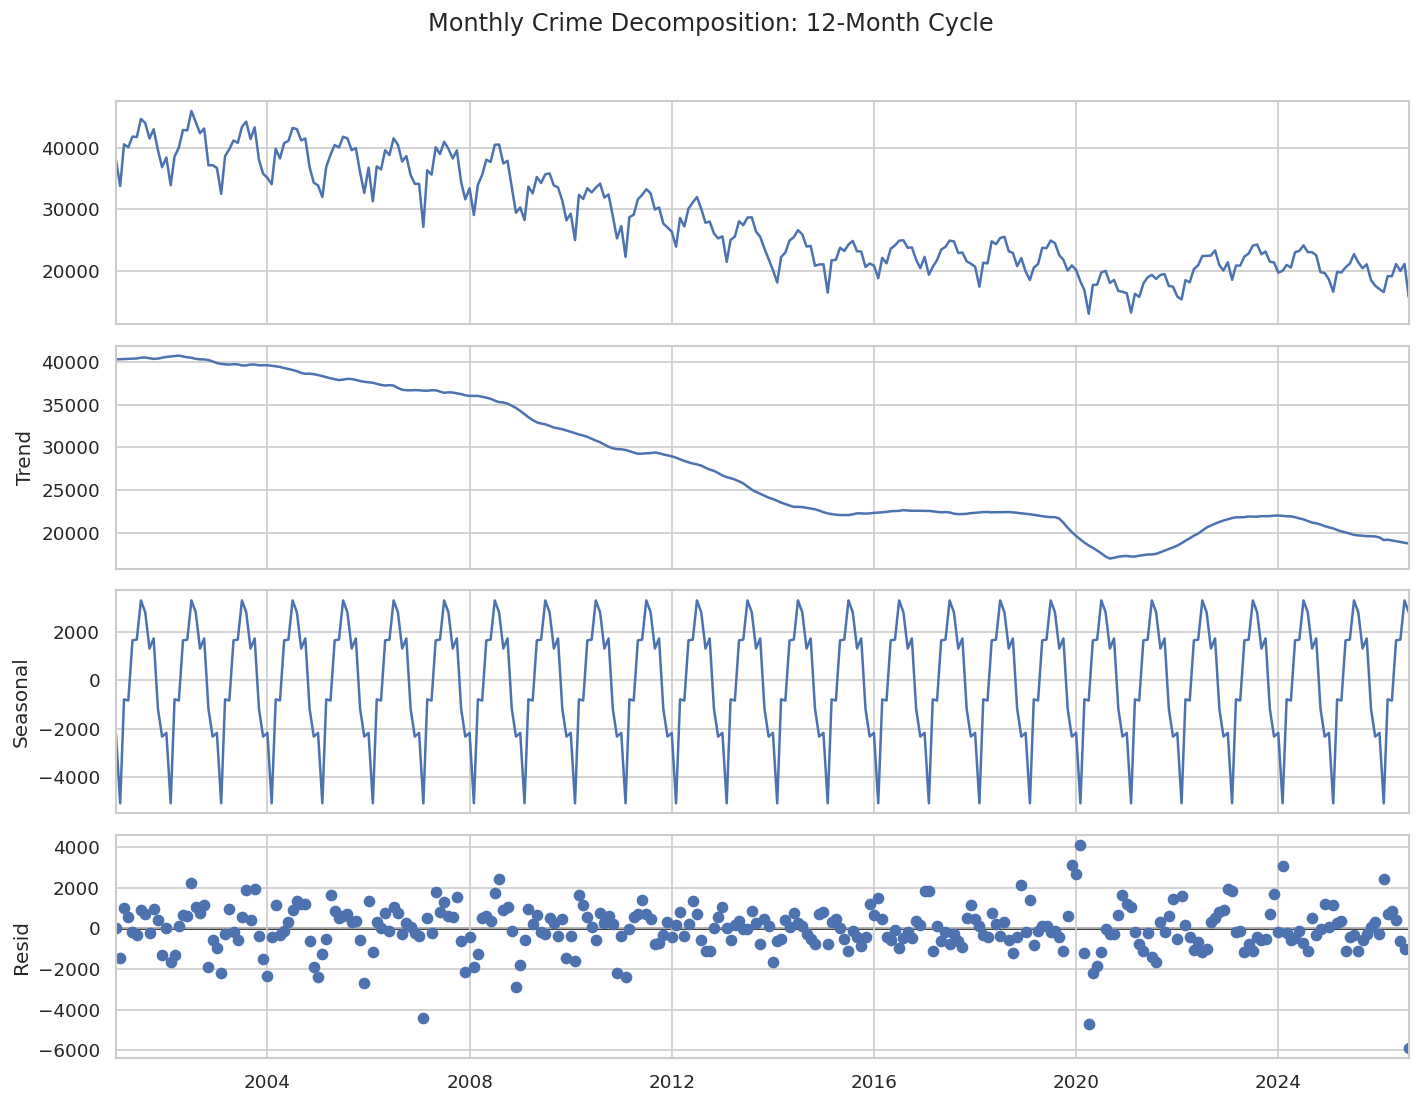

In [87]:
fig = annual_decomposition.plot()
fig.set_size_inches(12, 9)
fig.suptitle('Monthly Crime Decomposition: 12-Month Cycle', y=1.02)
fig.tight_layout()
plt.show()

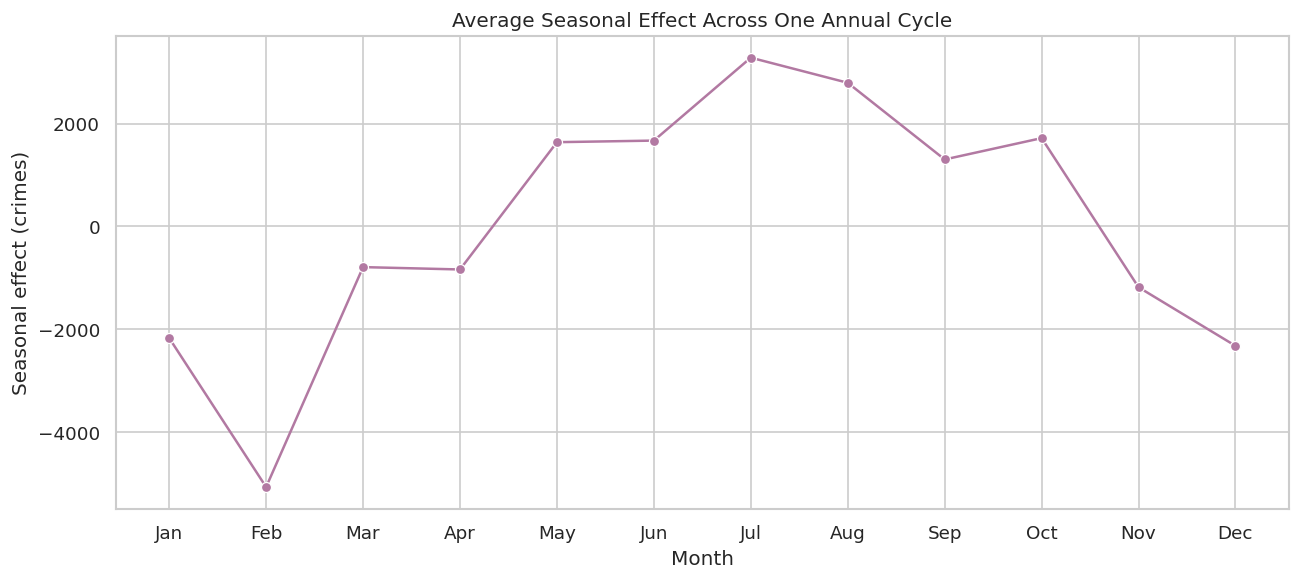

Cycle length: 12 months
Cycle magnitude: 8356.6 crimes
Highest seasonal point: Jul
Lowest seasonal point: Feb


In [89]:
month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]
monthly_pattern = (
    annual_decomposition.seasonal
    .groupby(annual_decomposition.seasonal.index.month)
    .mean()
)
monthly_pattern.index = month_labels
annual_magnitude = monthly_pattern.max() - monthly_pattern.min()
annual_peak_month = monthly_pattern.idxmax()
annual_low_month = monthly_pattern.idxmin()

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(
    x=monthly_pattern.index,
    y=monthly_pattern.values,
    marker='o',
    color='#B279A2',
    ax=ax
)
ax.set(
    title='Average Seasonal Effect Across One Annual Cycle',
    xlabel='Month',
    ylabel='Seasonal effect (crimes)'
)
fig.tight_layout()
plt.show()

print('Cycle length: 12 months')
print(f'Cycle magnitude: {annual_magnitude:.1f} crimes')
print(f'Highest seasonal point: {annual_peak_month}')
print(f'Lowest seasonal point: {annual_low_month}')